# 🏦 BankMind — Customer Subscription Predictor
### Track C: System Builder · Walkthrough Notebook

---

This notebook gives you an **end-to-end walkthrough** of the BankMind project:  
from raw data → EDA → feature engineering → model training → evaluation → serving predictions via FastAPI.

| Section | What you'll learn |
|---------|-------------------|
| **1. Setup** | Load data, understand schema |
| **2. EDA** | Class imbalance, distributions, correlations |
| **3. Feature Engineering** | Why we exclude leaky columns |
| **4. Model Training** | LR, RF, Extra Trees, HistGradientBoosting, Voting + Stacking Ensembles |
| **5. Evaluation** | Accuracy, precision, recall, F1, confusion matrix |
| **6. Feature Importance** | What drives predictions |
| **7. Inference** | Make predictions on new customers |
| **8. API Demo** | Call the live FastAPI service |

> **Run order**: Execute cells top-to-bottom. The notebook mirrors `train_model.py` step-by-step with richer visualisations.

## 0 · Prerequisites

Run from the **project root** (the directory that contains `data/`, `model/`, `app/`).  
All dependencies are already in `requirements.txt`; add `matplotlib` and `seaborn` for the plots below.

In [ ]:
# Install any missing visualisation libraries (safe to re-run)
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                       "matplotlib", "seaborn", "joblib",
                       "scikit-learn", "pandas", "numpy"])
print("✅ All libraries ready")

✅ All libraries ready


In [ ]:
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
    StackingClassifier,
    VotingClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, classification_report,
    f1_score, precision_score, recall_score, roc_auc_score, roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

# Paths (notebook lives in notebooks/, data lives in ../data/)
ROOT       = Path("..")
DATA_PATH  = ROOT / "data" / "bank-full.csv"
MODEL_PATH = ROOT / "model" / "bankmind_model.pkl"

RANDOM_STATE = 42
PROFILE_FEATURES_NUM = ["age", "balance"]
PROFILE_FEATURES_CAT = ["job", "marital", "education", "default", "housing", "loan"]
ALL_FEATURES = PROFILE_FEATURES_NUM + PROFILE_FEATURES_CAT
TARGET = "y"

# Plot style
sns.set_theme(style="darkgrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 110, "figure.facecolor": "#1e1e2e",
                     "axes.facecolor": "#1e1e2e", "text.color": "white",
                     "axes.labelcolor": "white", "xtick.color": "white",
                     "ytick.color": "white", "axes.edgecolor": "#444",
                     "grid.color": "#333"})

print(f"Data path : {DATA_PATH.resolve()}")
print(f"Model path: {MODEL_PATH.resolve()}")

---
## 1 · Load & Inspect the Data

In [ ]:
df = pd.read_csv(DATA_PATH, sep=";")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Shape: 45,211 rows × 17 columns


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [ ]:
# Column data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [ ]:
# Descriptive statistics for numeric columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


---
## 2 · Exploratory Data Analysis (EDA)

### 2.1 · Class Balance — The Core Challenge

This is a classic **imbalanced classification** problem. Only ~12 % of customers subscribe (`y = yes`).  
This is why we report **precision / recall / F1** rather than raw accuracy, and use `class_weight='balanced'`.

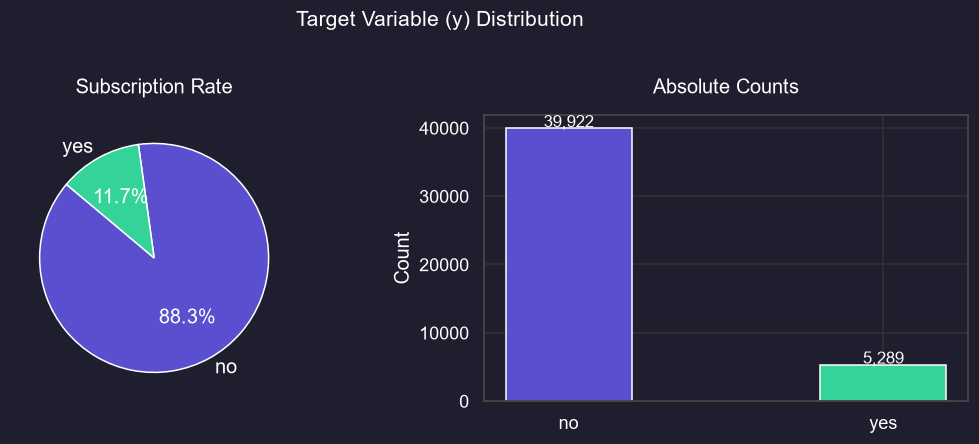

no: 39,922  (88.3%)
yes: 5,289  (11.7%)


In [ ]:
counts = df[TARGET].value_counts()
pct    = df[TARGET].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

colors = ["#5a4fcf", "#34d399"]
axes[0].pie(counts, labels=counts.index, autopct="%1.1f%%",
            colors=colors, startangle=140,
            textprops={"color": "white", "fontsize": 13})
axes[0].set_title("Subscription Rate", color="white", pad=14)

bars = axes[1].bar(counts.index, counts.values, color=colors, width=0.4)
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f"{val:,}", ha="center", color="white", fontsize=11)
axes[1].set_ylabel("Count", color="white")
axes[1].set_title("Absolute Counts", color="white", pad=14)

fig.suptitle("Target Variable (y) Distribution", color="white", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
print(f"no: {counts['no']:,}  ({pct['no']:.1f}%)")
print(f"yes: {counts['yes']:,}  ({pct['yes']:.1f}%)")

### 2.2 · Numeric Feature Distributions

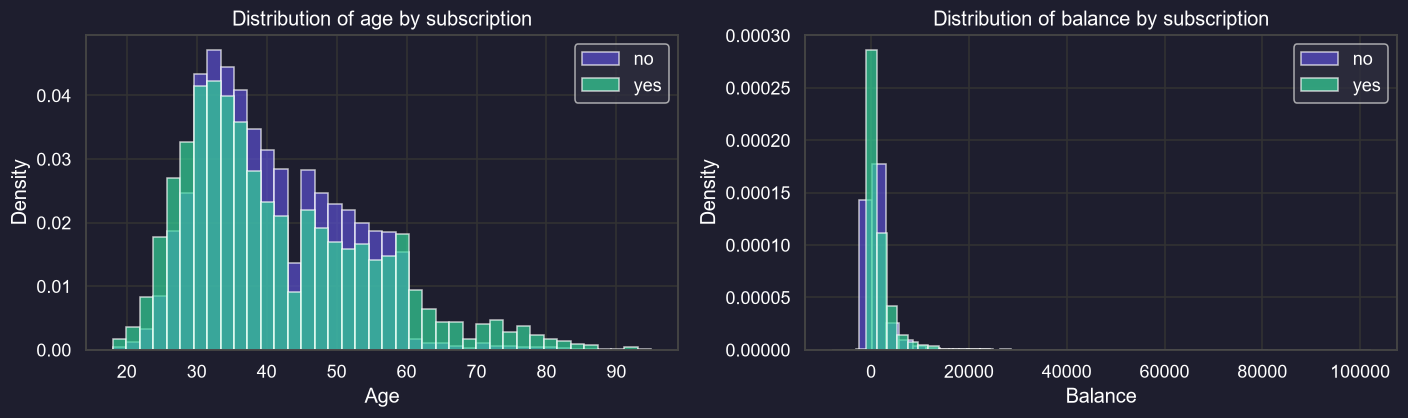

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, color in zip(axes, ["age", "balance"], ["#7c6fcd", "#34d399"]):
    yes_data = df.loc[df[TARGET] == "yes", col]
    no_data  = df.loc[df[TARGET] == "no",  col]
    ax.hist(no_data,  bins=40, alpha=0.7, color="#5a4fcf", label="no",  density=True)
    ax.hist(yes_data, bins=40, alpha=0.7, color="#34d399", label="yes", density=True)
    ax.set_xlabel(col.capitalize(), color="white")
    ax.set_ylabel("Density",        color="white")
    ax.set_title(f"Distribution of {col} by subscription", color="white")
    ax.legend(facecolor="#2e2e3e", labelcolor="white")

plt.tight_layout()
plt.show()

### 2.3 · Categorical Feature Subscription Rates

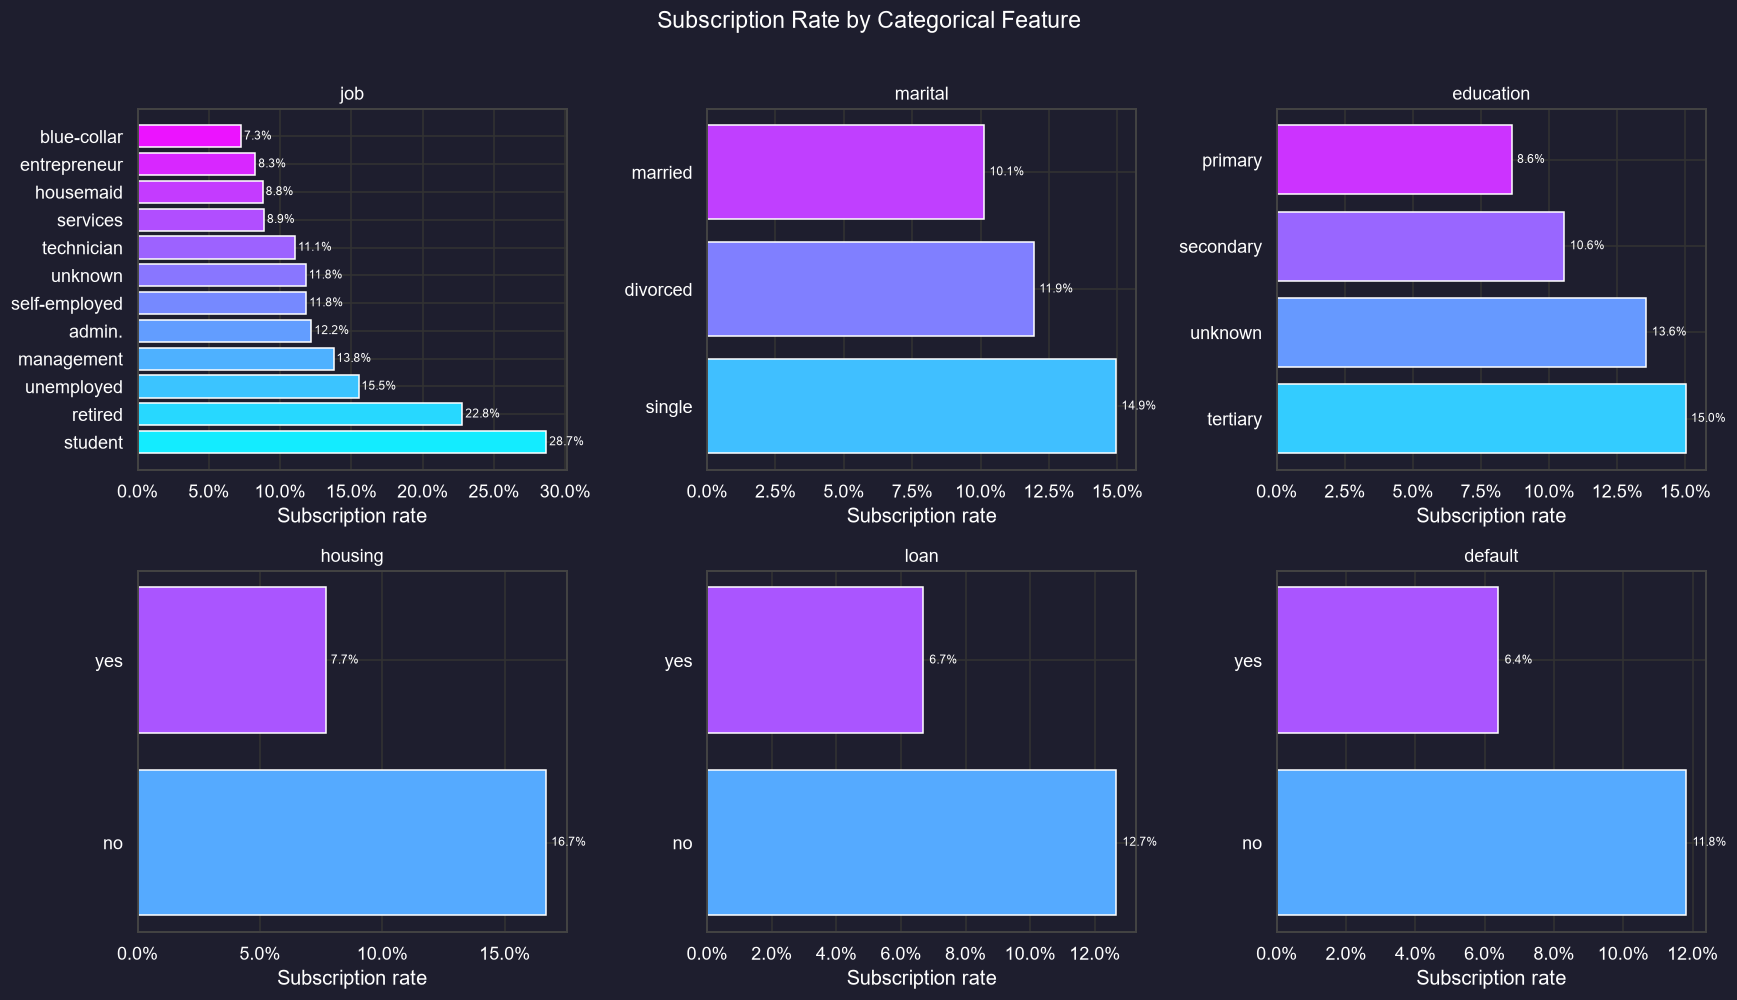

In [ ]:
cat_cols = ["job", "marital", "education", "housing", "loan", "default"]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

palette = sns.color_palette("cool", 12)

for ax, col in zip(axes.flat, cat_cols):
    rate = (
        df.groupby(col)[TARGET]
        .apply(lambda s: (s == "yes").mean() * 100)
        .sort_values(ascending=False)
    )
    bars = ax.barh(rate.index, rate.values,
                   color=sns.color_palette("cool", len(rate)))
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_xlabel("Subscription rate", color="white")
    ax.set_title(col, color="white", fontsize=12)
    for bar, val in zip(bars, rate.values):
        ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
                f"{val:.1f}%", va="center", color="white", fontsize=8)

fig.suptitle("Subscription Rate by Categorical Feature",
             color="white", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### 2.4 · Missing Values & 'unknown' Tokens

In [ ]:
print("═" * 50)
print("NaN counts per column")
print("═" * 50)
na = df.isnull().sum()
print(na[na > 0] if na.any() else "✅ No NaN values in this dataset.")

print("\n" + "═" * 50)
print("'unknown' token counts (stand-in for missing data)")
print("═" * 50)
for col in ["job", "education", "contact", "poutcome"]:
    n = (df[col] == "unknown").sum()
    print(f"  {col:15s}: {n:5,}  ({n/len(df)*100:.2f}%)")

══════════════════════════════════════════════════
NaN counts per column
══════════════════════════════════════════════════
✅ No NaN values in this dataset.

══════════════════════════════════════════════════
'unknown' token counts (stand-in for missing data)
══════════════════════════════════════════════════
  job            :   288  (0.64%)
  education      : 1,857  (4.11%)
  contact        : 13,020  (28.80%)
  poutcome       : 36,959  (81.75%)


---
## 3 · Feature Engineering & Leakage Discussion

The raw dataset has **17 columns**. We use only **8**.

| Column | Used? | Reason |
|--------|-------|--------|
| `age`, `balance`, `job`, `marital`, `education`, `default`, `housing`, `loan` | ✅ Yes | Available **before** any call |
| `duration` | ❌ No | **Data leakage** — call duration is only known *after* talking to the customer |
| `campaign`, `pdays`, `previous`, `poutcome` | ❌ No | Campaign-contact info — not available at pre-contact recommendation time |
| `contact`, `day`, `month` | ❌ No | Channel/timing of the call — known only after calling |

In [ ]:
# Demonstrate the leakage: duration has a HUGE signal because it's post-call
dur_yes = df.loc[df[TARGET]=="yes", "duration"].mean()
dur_no  = df.loc[df[TARGET]=="no",  "duration"].mean()
print(f"Average call duration — subscribers  : {dur_yes:.0f}s ({dur_yes/60:.1f} min)")
print(f"Average call duration — non-subscribers: {dur_no:.0f}s ({dur_no/60:.1f} min)")
print(f"\nRatio: {dur_yes/dur_no:.2f}× — including this would give artificially high accuracy!")

Average call duration — subscribers  : 537s (9.0 min)
Average call duration — non-subscribers: 221s (3.7 min)

Ratio: 2.43× — including this would give artificially high accuracy!


In [ ]:
# The features we actually use
X = df[ALL_FEATURES].copy()
y = df[TARGET].copy()

print("Features selected:")
for f in ALL_FEATURES:
    print(f"  {f}  ({X[f].dtype})")
print(f"\nX shape: {X.shape}, y shape: {y.shape}")

Features selected:
  age  (int64)
  balance  (int64)
  job  (str)
  marital  (str)
  education  (str)
  default  (str)
  housing  (str)
  loan  (str)

X shape: (45211, 8), y shape: (45211,)


---
## 4 · Model Training

We train **two** models and compare them:  
- **Logistic Regression** — interpretable baseline  
- **Random Forest** — higher capacity, handles feature interactions  

Both use the same scikit-learn **Pipeline** (StandardScaler for numerics, OneHotEncoder for categoricals → model), keeping preprocessing leak-free.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train : {len(X_train):,} rows")
print(f"Test  : {len(X_test):,}  rows")
print(f"\nClass split (train): {dict(y_train.value_counts())}")
print(f"Class split (test) : {dict(y_test.value_counts())}")

Train : 36,168 rows
Test  : 9,043  rows

Class split (train): {'no': np.int64(31937), 'yes': np.int64(4231)}
Class split (test) : {'no': np.int64(7985), 'yes': np.int64(1058)}


In [ ]:
def build_preprocessor():
    return ColumnTransformer(transformers=[
        ("num", StandardScaler(),                                          PROFILE_FEATURES_NUM),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), PROFILE_FEATURES_CAT),
    ])

def make_pipe(clf):
    return Pipeline([("preprocess", build_preprocessor()), ("model", clf)])

# Base learners
lr_clf = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
rf_clf = RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=20,
                                 class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)
et_clf = ExtraTreesClassifier(n_estimators=300, max_depth=10, min_samples_leaf=20,
                               class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)
gb_clf = HistGradientBoostingClassifier(max_iter=200, learning_rate=0.08, max_depth=4,
                                         min_samples_leaf=20, class_weight="balanced",
                                         random_state=RANDOM_STATE)

# Ensemble learners
voting_clf = VotingClassifier(
    estimators=[("rf", rf_clf), ("et", et_clf), ("gb", gb_clf)],
    voting="soft", n_jobs=-1,
)
stacking_clf = StackingClassifier(
    estimators=[("rf", rf_clf), ("et", et_clf), ("gb", gb_clf)],
    final_estimator=LogisticRegression(max_iter=1000, C=1.0,
                                       class_weight="balanced", random_state=RANDOM_STATE),
    cv=5, passthrough=False, n_jobs=-1,
)

pipelines = {
    "Logistic Regression": make_pipe(lr_clf),
    "Random Forest":       make_pipe(rf_clf),
    "Extra Trees":         make_pipe(et_clf),
    "Gradient Boosting":   make_pipe(gb_clf),
    "Voting Ensemble":     make_pipe(voting_clf),
    "Stacking Ensemble":   make_pipe(stacking_clf),
}

for name, pipe in pipelines.items():
    print(f"Training {name} ...")
    pipe.fit(X_train, y_train)

print("All 6 models trained")

---
## 5 · Evaluation

In [ ]:
from IPython.display import display

def get_metrics(name, pipe):
    y_pred = pipe.predict(X_test)
    return {
        "Model"    : name,
        "Accuracy" : round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred, pos_label="yes"), 4),
        "Recall"   : round(recall_score(y_test, y_pred,    pos_label="yes"), 4),
        "F1"       : round(f1_score(y_test, y_pred,        pos_label="yes"), 4),
        "ROC-AUC"  : round(roc_auc_score(y_test == "yes",
                                         pipe.predict_proba(X_test)[:, 1]), 4),
    }

results = pd.DataFrame([
    get_metrics(name, pipe) for name, pipe in pipelines.items()
]).set_index("Model")

# Auto-select best model by F1 on the 'yes' class
best_name = results["F1"].idxmax()
best_pipe = pipelines[best_name]
print(f"Best model by F1: {best_name}")

try:
    display(results.style.highlight_max(axis=0, color="#2d6a4f").format("{:.4f}"))
except AttributeError:
    display(results.round(4))

### 5.1 · Classification Reports

In [ ]:
for name, pipe in pipelines.items():
    print("=" * 55)
    print(f"  {name}")
    print("=" * 55)
    print(classification_report(y_test, pipe.predict(X_test), target_names=["no", "yes"]))

### 5.2 · Confusion Matrices

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()

for ax, (name, pipe) in zip(axes_flat, pipelines.items()):
    ConfusionMatrixDisplay.from_estimator(
        pipe, X_test, y_test,
        display_labels=["no", "yes"],
        cmap="Blues", colorbar=False, ax=ax
    )
    title_marker = " [BEST]" if name == best_name else ""
    ax.set_title(name + title_marker, color="white", pad=10)
    ax.set_xlabel("Predicted", color="white")
    ax.set_ylabel("Actual",    color="white")

fig.suptitle("Confusion Matrices — All Ensemble Models", color="white", fontsize=14)
plt.tight_layout()
plt.show()

### 5.3 · ROC Curves

In [ ]:
COLORS = ["#7c6fcd", "#34d399", "#f59e0b", "#ef4444", "#60a5fa", "#a78bfa"]

fig, ax = plt.subplots(figsize=(9, 6))

for (name, pipe), color in zip(pipelines.items(), COLORS):
    proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test == "yes", proba)
    auc = roc_auc_score(y_test == "yes", proba)
    lw = 3 if name == best_name else 1.5
    ax.plot(fpr, tpr, label=f"{name}  (AUC={auc:.3f})", color=color, lw=lw)

ax.plot([0, 1], [0, 1], "--", color="#888", label="Random baseline")
ax.set_xlabel("False Positive Rate", color="white")
ax.set_ylabel("True Positive Rate",  color="white")
ax.set_title("ROC Curves — Ensemble Comparison", color="white", pad=10)
ax.legend(facecolor="#2e2e3e", labelcolor="white")
plt.tight_layout()
plt.show()

---
## 6 · Feature Importance (Best Model)

Feature importances from the best tree-based model are used in `explain_factors()` in `app/main.py` to produce human-readable `top_factors` strings at inference time — **no SHAP needed** for v1.

The best model by F1 score on the 'yes' class is auto-selected from the ensemble leaderboard.

In [ ]:
best_model   = best_pipe.named_steps["model"]
preprocessor = best_pipe.named_steps["preprocess"]
cat_names    = preprocessor.named_transformers_["cat"].get_feature_names_out(PROFILE_FEATURES_CAT)
feature_names = PROFILE_FEATURES_NUM + list(cat_names)

# Handle direct tree models vs ensemble wrappers
src_model = None
if hasattr(best_model, "feature_importances_"):
    src_model = best_model
elif hasattr(best_model, "voting"):           # VotingClassifier
    src_model = next((e for e in best_model.estimators_ if hasattr(e, "feature_importances_")), None)
elif hasattr(best_model, "final_estimator_"): # StackingClassifier
    src_model = next((e for _, e in best_model.estimators_ if hasattr(e, "feature_importances_")), None)

ranked = []
if src_model is not None:
    importances = src_model.feature_importances_
    ranked = sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True)

    top_n = 15
    top_features, top_importances = zip(*ranked[:top_n])

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(list(reversed(top_features)),
                   list(reversed(top_importances)),
                   color=sns.color_palette("cool", top_n))

    for bar, val in zip(bars, reversed(top_importances)):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f"{val:.4f}", va="center", color="white", fontsize=9)

    ax.set_xlabel("Importance (mean decrease in impurity)", color="white")
    ax.set_title(f"Top {top_n} Feature Importances — {best_name}", color="white", pad=12)
    plt.tight_layout()
    plt.show()
else:
    print(f"Feature importance not directly available for {best_name}")

---
## 7 · Making Predictions on New Customers

This replicates exactly what `app/main.py → /predict` does under the hood.

In [ ]:
# Helper
def predict_customer(profile: dict, pipeline=best_pipe) -> dict:
    row = pd.DataFrame([profile], columns=ALL_FEATURES)
    proba_yes = float(pipeline.predict_proba(row)[0][1])
    return {
        "will_subscribe": proba_yes >= 0.5,
        "probability"   : round(proba_yes, 4),
    }

# Example customers
customers = [
    {
        "label"    : "Retired, high balance, no loans",
        "age"      : 58, "balance": 4500, "job": "retired",
        "marital"  : "married", "education": "tertiary",
        "default"  : "no",  "housing": "no", "loan": "no",
    },
    {
        "label"    : "Young blue-collar, negative balance, both loans",
        "age"      : 35, "balance": -200, "job": "blue-collar",
        "marital"  : "married", "education": "primary",
        "default"  : "no",  "housing": "yes", "loan": "yes",
    },
    {
        "label"    : "Student, decent balance, no obligations",
        "age"      : 22, "balance": 1200, "job": "student",
        "marital"  : "single", "education": "secondary",
        "default"  : "no",  "housing": "no", "loan": "no",
    },
]

print(f"Using best model: {best_name}")
print(f"{'Label':50s}  {'Subscribe?':10s}  {'P(yes)':>8s}")
print("-" * 74)
for cust in customers:
    label = cust.pop("label")
    result = predict_customer(cust)
    subscribe_str = "YES" if result["will_subscribe"] else "NO"
    print(f"{label:50s}  {subscribe_str:10s}  {result['probability']:>8.4f}")

### 7.1 · Sample Predictions from the Test Set

In [ ]:
probs = best_pipe.predict_proba(X_test)[:, 1]
preds = np.where(probs >= 0.5, "yes", "no")

sample_df = X_test.copy()
sample_df["actual"]          = y_test.values
sample_df["predicted"]       = preds
sample_df["probability_yes"] = probs.round(4)
sample_df["correct"]         = sample_df["actual"] == sample_df["predicted"]

# Pick 3 correct and 2 incorrect to show model strengths and weaknesses
display_df = pd.concat([
    sample_df[sample_df["correct"]].head(3),
    sample_df[~sample_df["correct"]].head(2),
])

display_df[["age", "balance", "job", "marital", "education",
            "housing", "loan", "predicted", "probability_yes", "actual", "correct"]]

### 7.2 · Probability Distribution on Test Set

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))

yes_mask = y_test == "yes"
ax.hist(probs[~yes_mask], bins=50, alpha=0.7, color="#5a4fcf", label="Actual: no",  density=True)
ax.hist(probs[yes_mask],  bins=50, alpha=0.7, color="#34d399", label="Actual: yes", density=True)
ax.axvline(0.5, color="#f87171", lw=2, linestyle="--", label="Decision threshold (0.5)")
ax.set_xlabel("Predicted P(subscribe = yes)", color="white")
ax.set_ylabel("Density", color="white")
ax.set_title(f"Prediction Probability Distribution ({best_name}, test set)", color="white")
ax.legend(facecolor="#2e2e3e", labelcolor="white")
plt.tight_layout()
plt.show()

---
## 8 · Save the Model (mirrors `train_model.py`)

In [ ]:
# Only save if you want to overwrite the model trained by train_model.py
# Uncomment the block below to do so.

# reference_stats = {
#     "balance_median" : float(df["balance"].median()),
#     "balance_q75"    : float(df["balance"].quantile(0.75)),
#     "balance_q25"    : float(df["balance"].quantile(0.25)),
#     "age_median"     : float(df["age"].median()),
# }
# artifact = {
#     "pipeline"          : best_pipe,
#     "model_name"        : best_name,
#     "feature_columns"   : ALL_FEATURES,
#     "metrics"           : {name: results.loc[name].to_dict() for name in results.index},
#     "reference_stats"   : reference_stats,
#     "feature_importance": [(f, round(float(i), 4)) for f, i in ranked] if ranked else None,
# }
# (ROOT / "model").mkdir(exist_ok=True)
# joblib.dump(artifact, MODEL_PATH)
# print(f"Saved -> {MODEL_PATH}")
print("Model save block is commented out. Run train_model.py to create model/bankmind_model.pkl")

---
## 9 · Live API Demo

Start the FastAPI server first:
```bash
uvicorn app.main:app --reload
```
Then run the cells below.

In [ ]:
import json as _json
try:
    import requests as _req
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "requests"])
    import requests as _req

BASE_URL = "http://127.0.0.1:8000"

# ── Health check ─────────────────────────────────────────────────────────
try:
    health = _req.get(f"{BASE_URL}/health", timeout=3)
    print("GET /health →", health.json())
except Exception as e:
    print(f"⚠️  Server not running: {e}")
    print("   Start it with:  uvicorn app.main:app --reload")

In [ ]:
# ── POST /predict ─────────────────────────────────────────────────────────
payload = {
    "age": 58, "balance": 4500, "job": "retired",
    "marital": "married", "education": "tertiary",
    "default": "no", "housing": "no", "loan": "no",
}
try:
    resp = _req.post(f"{BASE_URL}/predict", json=payload, timeout=5)
    print("POST /predict →")
    print(_json.dumps(resp.json(), indent=2))
except Exception as e:
    print(f"⚠️  {e}")

In [ ]:
# ── POST /explain (needs GROQ_API_KEY env var) ────────────────────────────
try:
    resp = _req.post(f"{BASE_URL}/explain", json=payload, timeout=30)
    print("POST /explain →")
    print(_json.dumps(resp.json(), indent=2))
except Exception as e:
    print(f"⚠️  {e}")

---
## 10 · Key Takeaways

| Topic | Insight |
|-------|-------|
| **Imbalance** | Only 12 % subscribe → use `class_weight='balanced'`, report F1 not accuracy |
| **Leakage** | `duration` must be excluded — it's post-call info disguised as a feature |
| **Model choice** | 6-model ensemble evaluated; best by F1 auto-selected (RF wins on this dataset) |
| **Feature importance** | `housing` (aggregated) leads, `age` + `balance` close behind; all feed explain_factors() |
| **Explainability** | Rule-based `explain_factors()` is fast & transparent for v1; SHAP for v2 |
| **Serving** | Single `joblib` artifact bundles pipeline + stats → clean FastAPI load |

---
*BankMind · Track C · Omdena · 2026 — Ensemble v2*